<a href="https://colab.research.google.com/github/Kaveesha-Vihanga/DS_Project/blob/component-3/Component_3_Implementation_zero_shot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from transformers import pipeline
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
np.random.seed(42)

In [ ]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/DSGP Component 3/sri_lanka_hotel_reviews_english.csv')

# Check columns
print(df.columns)
print(df[['review_clean', 'Rating']].head())

Index(['User Name', 'Country', 'Room Info', 'Stay Date', 'Traveller Type',
       'Rating', 'Review Date', 'Hotel Name', 'Address', 'review_full',
       'review_clean', 'clean_date', 'word_count', 'language'],
      dtype='object')
                                        review_clean  Rating
0  Good Rooms were good I was expected to check o...     7.0
1  Good Clean and close to beach Road noise at night     7.0
2             Pls talk to politle Expensive Location     7.0
3  AAA+++ Very friendly staff, very clean rooms a...     9.0
4  Calm, Nice place in the marine drive Really ni...     8.0


In [ ]:
aspects = [
    'rooms',
    'staff',
    'check-in/out',
    'cleanliness',
    'location',
    'value for money',
    'food',
    'amenities',
    'facilities'
]

sentiments = ['positive', 'negative']

candidate_labels = [f"{aspect} {sentiment}" for aspect in aspects for sentiment in sentiments]
print(candidate_labels)

['rooms positive', 'rooms negative', 'staff positive', 'staff negative', 'check-in/out positive', 'check-in/out negative', 'cleanliness positive', 'cleanliness negative', 'location positive', 'location negative', 'value for money positive', 'value for money negative', 'food positive', 'food negative', 'amenities positive', 'amenities negative', 'facilities positive', 'facilities negative']


In [ ]:
# Load the pipeline (this may take a minute)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0)

threshold = 0.5

# Initialize empty dummy columns for each candidate label
for label in candidate_labels:
    df[label] = 0

# Iterate over reviews (you can use .iloc for a subset to test first)
for i, review in enumerate(df['review_clean']):
    if pd.isna(review) or review.strip() == '':
        continue
    # Classify
    result = classifier(review, candidate_labels, multi_label=True)
    # For each label with score > threshold, set dummy to 1
    for label, score in zip(result['labels'], result['scores']):
        if score > threshold:
            df.loc[i, label] = 1

    # Optional: print progress
    if (i+1) % 100 == 0:
        print(f"Processed {i+1} reviews")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 100 reviews
Processed 200 reviews
Processed 300 reviews
Processed 400 reviews
Processed 500 reviews
Processed 600 reviews
Processed 700 reviews
Processed 800 reviews
Processed 900 reviews
Processed 1000 reviews
Processed 1100 reviews
Processed 1200 reviews
Processed 1300 reviews
Processed 1400 reviews
Processed 1500 reviews
Processed 1600 reviews
Processed 1700 reviews
Processed 1800 reviews
Processed 1900 reviews
Processed 2000 reviews
Processed 2100 reviews
Processed 2200 reviews
Processed 2300 reviews
Processed 2400 reviews
Processed 2500 reviews
Processed 2600 reviews
Processed 2700 reviews
Processed 2800 reviews
Processed 2900 reviews
Processed 3000 reviews
Processed 3100 reviews
Processed 3200 reviews
Processed 3300 reviews
Processed 3400 reviews
Processed 3500 reviews
Processed 3600 reviews
Processed 3700 reviews
Processed 3800 reviews
Processed 3900 reviews
Processed 4000 reviews
Processed 4100 reviews
Processed 4200 reviews
Processed 4300 reviews
Processed 4400 revie

In [ ]:
# Count occurrences of each label
label_counts = df[candidate_labels].sum().sort_values(ascending=False)
print("Label frequencies:\n", label_counts)

# Keep only labels that appear in at least, say, 5% of reviews or a minimum count
min_count = int(0.05 * len(df))
keep_labels = label_counts[label_counts >= min_count].index.tolist()
print(f"Keeping {len(keep_labels)} labels with >= {min_count} occurrences.")

X = df[keep_labels]
y = df['Rating']

# Add constant
X = sm.add_constant(X)

Label frequencies:
 amenities positive          14526
location positive           14506
facilities positive         14420
rooms positive              14179
check-in/out positive       14137
value for money positive    13985
staff positive              12901
cleanliness positive        11409
food positive                8429
check-in/out negative        3187
rooms negative               2789
location negative            2596
facilities negative          2587
amenities negative           2536
staff negative               2173
value for money negative     1980
cleanliness negative         1832
food negative                1565
dtype: int64
Keeping 18 labels with >= 812 occurrences.


In [ ]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     1160.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:04:54   Log-Likelihood:                -27494.
No. Observations:               16252   AIC:                         5.503e+04
Df Residuals:                   16233   BIC:                         5.517e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [ ]:
# Get coefficients and p-values
coef = model.params
pvals = model.pvalues

# Separate positive and negative labels for each aspect
results = []
for aspect in aspects:
    pos_label = f"{aspect} positive"
    neg_label = f"{aspect} negative"
    if pos_label not in coef.index or neg_label not in coef.index:
        continue
    pos_coef = coef[pos_label]
    pos_p = pvals[pos_label]
    neg_coef = coef[neg_label]
    neg_p = pvals[neg_label]

    # Significance at alpha = 0.1 (you can adjust)
    pos_sig = pos_p < 0.1
    neg_sig = neg_p < 0.1

    # Classify
    if pos_sig and not neg_sig:
        category = "Satisfier"
    elif neg_sig and not pos_sig:
        category = "Dissatisfier"
    elif pos_sig and neg_sig:
        # Compare magnitudes
        if abs(pos_coef) > abs(neg_coef) * 1.2:  # positive at least 20% larger
            category = "Satisfier-leaning hybrid"
        elif abs(neg_coef) > abs(pos_coef) * 1.2:
            category = "Dissatisfier-leaning hybrid"
        else:
            category = "Hybrid"
    else:
        category = "Insignificant"

    results.append({
        'aspect': aspect,
        'pos_coef': pos_coef,
        'pos_p': pos_p,
        'neg_coef': neg_coef,
        'neg_p': neg_p,
        'category': category
    })

result_df = pd.DataFrame(results)
print(result_df)

            aspect  pos_coef         pos_p  neg_coef         neg_p  \
0            rooms  0.013666  8.339833e-01 -0.314779  5.871279e-07   
1            staff  0.332039  1.091950e-15 -0.905687  2.601806e-62   
2     check-in/out  0.206193  3.494982e-04 -0.002006  9.680279e-01   
3      cleanliness  0.060348  4.203580e-02 -1.008700  3.042297e-76   
4         location  0.286592  1.677442e-06 -0.245919  9.055178e-07   
5  value for money  0.539911  2.702508e-21 -0.315196  2.232505e-07   
6             food  0.099078  1.343674e-05 -0.266366  8.167599e-09   
7        amenities  0.475672  1.831563e-08  0.128739  8.188561e-02   
8       facilities  0.401493  3.157087e-06 -0.087084  2.679096e-01   

                      category  
0                 Dissatisfier  
1  Dissatisfier-leaning hybrid  
2                    Satisfier  
3  Dissatisfier-leaning hybrid  
4                       Hybrid  
5     Satisfier-leaning hybrid  
6  Dissatisfier-leaning hybrid  
7     Satisfier-leaning hybrid  
8 

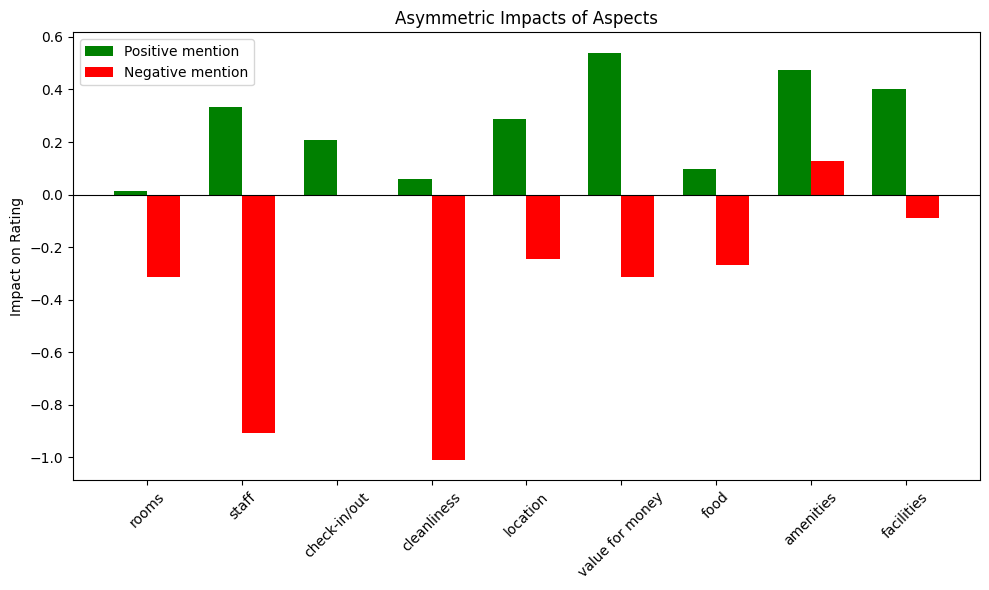

In [ ]:
plt.figure(figsize=(10, 6))
x = np.arange(len(result_df))
width = 0.35

plt.bar(x - width/2, result_df['pos_coef'], width, label='Positive mention', color='green')
plt.bar(x + width/2, result_df['neg_coef'], width, label='Negative mention', color='red')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, result_df['aspect'], rotation=45)
plt.ylabel('Impact on Rating')
plt.title('Asymmetric Impacts of Aspects')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Save the full dataframe with dummy variables
df.to_csv('/content/drive/MyDrive/DSGP Component 3/reviews_with_aspect_sentiments_ZEROSHOT.csv', index=False)
print("Saved reviews_with_aspect_sentiments.csv")

# 2. Save the classification results (aspects and their categories)
result_df.to_csv('/content/drive/MyDrive/DSGP Component 3/aspect_impact_classification_ZEROSHOT.csv', index=False)
print("Saved aspect_impact_classification.csv")

# 3. Save regression summary as a text file
with open('/content/drive/MyDrive/DSGP Component 3/regression_summary.txt', 'w') as f:
    f.write(model.summary().as_text())
print("Saved regression_summary.txt")

Saved reviews_with_aspect_sentiments.csv
Saved aspect_impact_classification.csv
Saved regression_summary.txt
